# Lax-Wendroff scheme

## Governing equation:

We start from the 1D linear advection equation:

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$

## Time discretisation - Taylor expansion in time:

Expand $u$ at time level $j+1$:

$$u_i^{j+1} = u_i^j + \Delta t \frac{\partial u}{\partial t} \Big|_i^j + \frac{\Delta t^2}{2} \frac{\partial^2 u}{\partial t^2} \Big|_i^j + \mathcal{O}(\Delta t^3)$$

### First time derivative

From the one-wave PDE:

$$\frac{\partial u}{\partial t} = -c \frac{\partial u}{\partial x}$$

### Second time derivative

Differentiate again in time (from the original 2-wave PDE):

$$\frac{\partial^2 u}{\partial t^2}= c^2 \frac{\partial^2 u}{\partial x^2}$$

### Substitute into Taylor expansion:

$$u_i^{j+1} = u_i^j - c \Delta t \frac{\partial u}{\partial x} + \frac{c^2 \Delta t^2}{2} \frac{\partial^2 u}{\partial x^2}$$

## Spatial discretisation

### First derivative (central difference)

$$\frac{\partial u}{\partial x} \Big|_i^j \approx \frac{u_{i+1}^j - u_{i-1}^j}{2 \Delta x}$$

### Second derivative (central difference)

$$\frac{\partial^2 u}{\partial x^2} \Big|_i^j \approx \frac{u_{i+1}^j - 2u_i^j + u_{i-1}^j}{\Delta x^2}$$


## Substitute discretisations

$$u_i^{j+1} = u_i^j - c\Delta t \frac{u_{i+1}^j - u_{i-1}^j}{2 \Delta x} + \frac{c^2\Delta t^2}{2}\frac{u_{i+1}^j - 2\,u_{i}^j + u_{i-1}^j} {\Delta x^2}$$

## Define Courant number

$$C = \frac{c\,\Delta t}{\Delta x}$$

## Final form of the Lax–Wendroff scheme:

$$u_i^{j+1} = u_i^j - \frac{C}{2} (u_{i+1}^j - u_{i-1}^j) + \frac{C^2}{2} (u_{i+1}^j - 2u_i^j + u_{i-1}^j)$$


And: 

$$\frac{u_i^{j+1} - u_i^j}{\Delta t} + c \frac{u_{i+1}^j - u_{i-1}^j}{2\Delta x} - \frac{\theta}{2\Delta t} \left( u_{i+1}^j - 2u_i^j + u_{i-1}^j \right) = 0$$

where: 

$$\theta = C^2 =\left (\frac{c\,\Delta t}{\Delta x}\right)^2$$


## Properties of the Lax–Wendroff scheme:

- It is second-order accurate in both space and time.

- It is an Explicit method.

## Exercise:

The objective is to solve the linear advection (transport) equation for a scalar field $u(x, t)$:

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0$$


**Domain**: $-2\le x\le 2\$

**Initial Condition**: A Gaussian distribution defined as:

$$u_{0}(x) = \exp\left(-\frac{1}{2}\left(\frac{x}{0.4}\right)^{2}\right)$$

**Boundary Conditions**: Periodic boundary conditions where:

$$u(-2, t) = u(+2, t)$$

**Advection Speed**: Constant velocity represented by $c$

In [1]:
# Import libraries

import matplotlib.pyplot as plt
import numpy as np

### 1. Space discretisation:

In [2]:
# Number of elements along the X axis
nx = 101

# Define the domain boundaries
x_max = +2.
x_min = -2.

# Resolution along x
delta_x = (x_max - x_min)/(nx - 1)
#print(delta_x)

# Generate the x vector
x = np.linspace(x_min, x_max, nx)
#print(x.shape)

### 2. Define the initial condition

In [3]:
# IC function
def u_x(x_axis):
    
    """
    This defines/returns a 1D Gaussian.
    
    Input: x -> x_axis
    Output: Gaussian
    """
    
    return np.exp(-0.5*(x/0.4)**2)


In [4]:
# Save the IC (Gaussian) into an object:

u_0 = u_x(x)

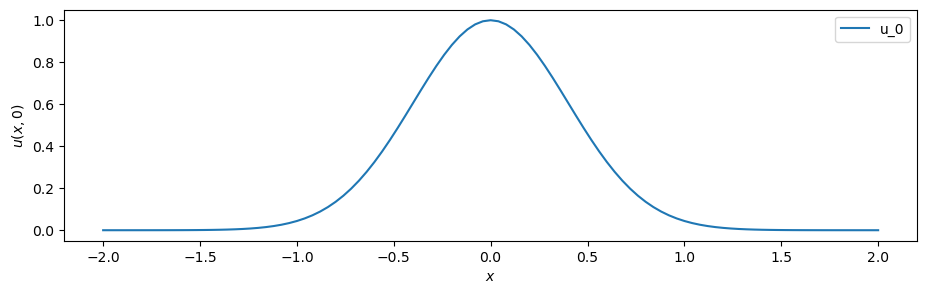

In [5]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(x, u_0, label = "u_0")

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,0)$")

plt.legend()

plt.show()



### 3. Time discretisation:

In [6]:
# CFL number
cfl = 0.8

# Speed perturbation
c = 1.

# Time step
delta_t = cfl*delta_x/c

#print(delta_t)

# Min/Max time:
t_min = 0.
t_max = 10.

# Time axis:

t = np.arange(t_min, t_max, delta_t)

#print(t.shape)

### 4. Define theta (i.e. the coef of parabolic term)


In [7]:
# For stability and consistency, theta = CFL^2

theta = cfl**2

#theta = -0.5

#print(theta)

### 5. Carry out the numerical integration

### Create Empty solution array

In [8]:
# Empty array

u_sln = np.zeros((len(t), len(x)))

#print(np.unique(u_sln))

### Adding initial condition:

In [9]:
u_sln[0, :] = u_0 # This is our Gaussian 

#print(u_sln[0, :])

#print(u_sln)

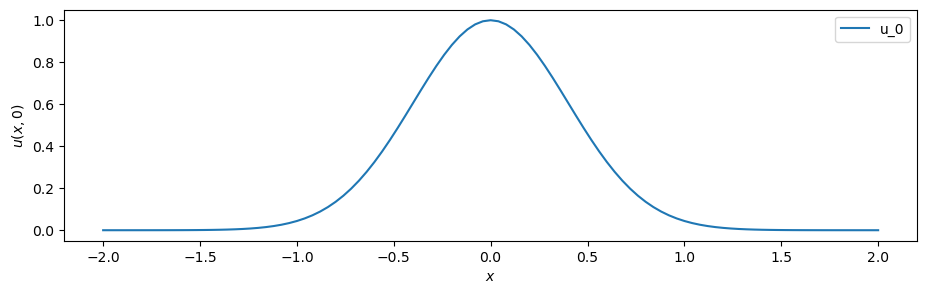

In [10]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(x, u_sln[0, :], label = "u_0")

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,0)$")

plt.legend()

plt.show()



### Integration step, time loop:

$$
 \begin{aligned}
\frac{u_i^{j+1} - u_i^j}{\Delta t} + c \frac{u_{j+1}^n - u_{j-1}^n}{2 \Delta x} - \frac{\theta}{2 \Delta t} \left( u_{i+1}^j - 2u_i^j + u_{i-1}^j \right)=0
\end{aligned}
$$

$$
 \begin{aligned}
\Rightarrow u_i^{j+1} = u_i^j - c\,\Delta t \frac{u_{i+1}^j + u_{i-1}^j}{2 \Delta x} + \frac{\theta}{2 } \left( u_{i+1}^j - 2u_i^j + u_{i-1}^j \right)
\end{aligned}
$$

In [11]:
for j in range(0, len(t) - 1):
    
    for i in range(1, nx - 1):
        
        # Lax-Wendroff scheme
        u_sln[j+1, i] = u_sln[j, i] - 0.5*cfl*(u_sln[j, i+1]\
        - u_sln[j, i-1]) + 0.5*theta*(u_sln[j, i+1]\
        - 2*u_sln[j, i] + u_sln[j, i-1]) 
        
    # Boundary conditions
    u_sln[j+1, 0] = u_sln[j, nx - 2]
    u_sln[j+1, nx - 1] = u_sln[j+1, 0]

#print(u_sln.shape)
        

In [12]:
#print(u_sln)

### Solution plot:

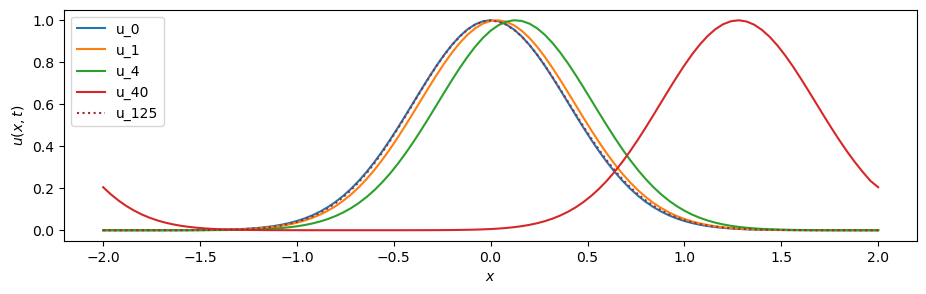

In [13]:
# Plotting

plt.figure(figsize=(11,3))

# Plot the IC -> Gaussian
plt.plot(x, u_sln[0, :], label = "u_0")

# The first time
plt.plot(x, u_sln[1, :], label = "u_1")

plt.plot(x, u_sln[4, :], label = "u_4")
plt.plot(x, u_sln[40, :], label = "u_40")
plt.plot(x, u_sln[125, :], label = "u_125", linestyle=":", color = "brown")

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,t)$")

plt.legend()

plt.show()



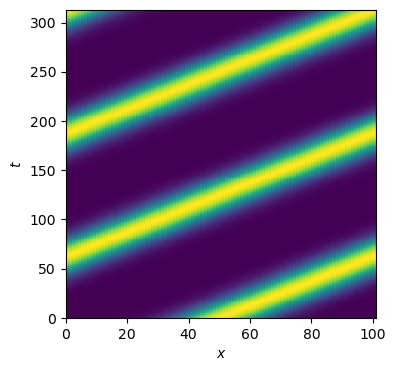

In [14]:
# Plotting

plt.figure(figsize=(4,4))

plt.pcolor(u_sln)

plt.xlabel(r"$x$")
plt.ylabel(r"$t$")

plt.show()

In [15]:
# Create a meshgrid
x_grid, t_grid = np.meshgrid(x, t)

#print(x_grid.shape, t_grid.shape)

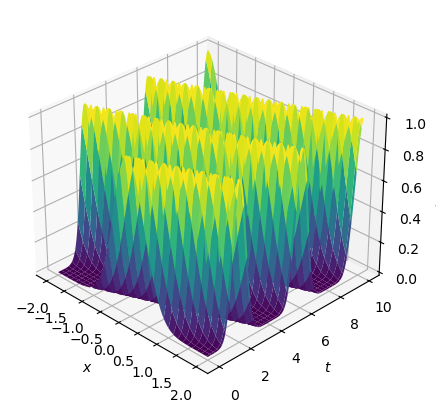

In [16]:
fig = plt.figure(figsize=(6,5))

ax = plt.axes(projection='3d')
ax.plot_surface(x_grid, t_grid, u_sln, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface

ax.set_xlabel(r'$x$')  # Customised labels for axes
ax.set_ylabel(r'$t$')
ax.set_zlabel(r'$u(x,t)$')

ax.view_init(30, -45)

plt.show()

### Stability Analysis (Von Neumann Method):

To determine the stability of the Lax-Wendroff scheme, we analyze the growth of a Fourier mode:

$$u_i^j = A^j e^{I(ki\Delta x)}$$

where $k$ is the wavenumber, $i$ is the spatial index, and $I \equiv \sqrt{-1}$.

#### Amplification Factor ($A$):

The amplification factor is defined as the ratio of the solution at the new time level ($j+1$) to the current level ($j$): 

$$A = \frac{A^{j+1}}{A^j}$$

Substituting the Fourier mode into the Lax-Wendroff discretization yields:

$$A = 1 - I\,C \sin(k\Delta x) + C^2 (\cos(k\Delta x) - 1)$$

Where $C = \frac{c\Delta t}{\Delta x}$ is the Courant number.

#### Magnitude of the Amplification Factor:

For the scheme to be stable, the magnitude of the amplification factor must satisfy $|A| \le 1$. The squared magnitude is calculated as:

$$|A|^2 = [1 + C^2(\cos(k\Delta x) - 1)]^2 + C^2 \sin^2(k\Delta x)$$

#### Stability Regimes:

The stability of the numerical solution depends on the relationship between the diffusion coeficient $\theta$ and the Courant number $C$:

| Case | Condition | Stability Result |
| :--- | :--- | :--- |
| **Pure Central Scheme** | $\theta = 0$ | **Unconditionally unstable** ($|A| > 1$ for all non-zero $k$). |
| **Lax-Wendroff Scheme** | $\theta = C^2$ | **Stable** if $|C| \le 1$. |
| **General Scheme** | $C^2 \le \theta \le 1$ | **Stable** within this parameter range. |

### Final Stability Condition:

The Lax-Wendroff method is stable provided that the Courant-Friedrichs-Lewy (CFL) condition is satisfied:

$$|C| = \left| \frac{c\Delta t}{\Delta x} \right| \le 1$$